In [28]:
import pandas as pd
df = pd.read_csv("Salary_Data.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [29]:

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [30]:
#slicing the dataset
x=df.iloc[:,0:1].values
y=df.iloc[:,-1].values
print(x)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [31]:
#splitting the dataset into training set and testing set 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=1/3,random_state=0)


In [32]:
print(df.shape)

(30, 2)


In [33]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(20, 1)
(10, 1)
(20,)
(10,)


In [34]:
#calculate the mean values of input and output
import numpy as np
x_mean = np.mean(x_train)
y_mean = np.mean(y_train)
print(x_mean,y_mean)

4.7299999999999995 71022.5


In [35]:
#calculate intercept and coefficient
n = len(x_train)
num,den = 0,0
for i in range(n):
    num+=(x_train[i]-x_mean)*(y_train[i]-y_mean)
    den+=(x_train[i]-x_mean)**2

b1 = num/den
b0 = y_mean - (b1*x_mean)
print("b0:",b0)
print("b1:",b1)

b0: [26816.19224403]
b1: [9345.94244312]


In [36]:
#predicting results on test dataset
y_pred_code = b0+b1*x_test
print(y_pred_code)

[[ 40835.10590871]
 [123079.39940819]
 [ 65134.55626083]
 [ 63265.36777221]
 [115602.64545369]
 [108125.8914992 ]
 [116537.23969801]
 [ 64199.96201652]
 [ 76349.68719258]
 [100649.1375447 ]]


In [37]:
print(y_test)
print("\n ",x_test)

[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]

  [[ 1.5]
 [10.3]
 [ 4.1]
 [ 3.9]
 [ 9.5]
 [ 8.7]
 [ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]]


In [38]:
#mean square error
n1 = len(y_test)
mse = 0
for i in range(n1):
    mse+=(y_test[i]-y_pred_code[i])**2

mse = mse/n1
print(mse)

#root mean square error
rmse = np.sqrt(mse)S
print(rmse)

[21026037.3295113]
[4585.41572047]


MACHINE LEARNING ALGORITHM

In [39]:
#create an object of the algorithm /model
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [41]:
#train the model
reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
#predict the model on testing dataset
y_pred = reg.predict(x_test)
print(y_pred)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [45]:
#calculate the intercept and the coefficient
print("intercept",reg.intercept_)
print("coefficient",reg.coef_)

intercept 26816.19224403119
coefficient [9345.94244312]


In [46]:
#evaluation metrics
from sklearn import metrics
print("mean absolute error:")
print(metrics.mean_absolute_error(y_test,y_pred))

mean absolute error:
3426.4269374307123


In [50]:
#evaluation metrics
from sklearn import metrics
print("mean absolute error:",metrics.mean_absolute_error(y_test,y_pred))
print("mean squared error:",metrics.mean_squared_error(y_test,y_pred))
print("root mean squared error:", np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

mean absolute error: 3426.4269374307123
mean squared error: 21026037.329511296
root mean squared error: 4585.4157204675885


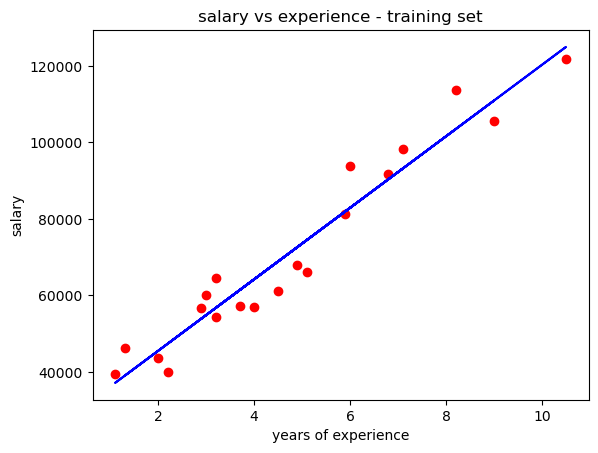

In [53]:
#visualization
import matplotlib.pyplot as plt
plt.scatter(x_train,y_train,color="red")
plt.plot(x_train,reg.predict(x_train),color="blue")
plt.title("salary vs experience - training set")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()

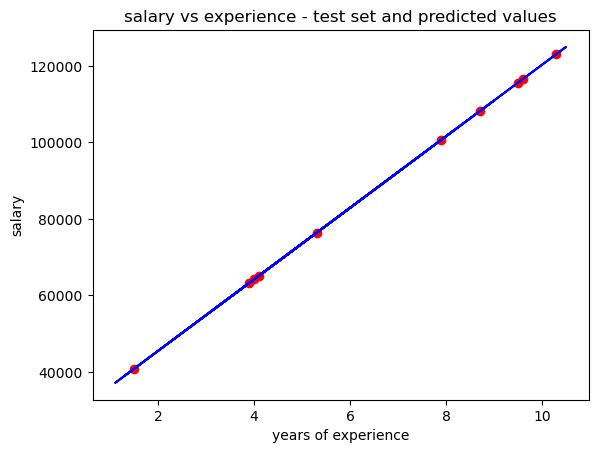

In [54]:
#visualization
plt.scatter(x_test,y_pred,color="red")
plt.plot(x_train,reg.predict(x_train),color="blue")
plt.title("salary vs experience - test set and predicted values")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()

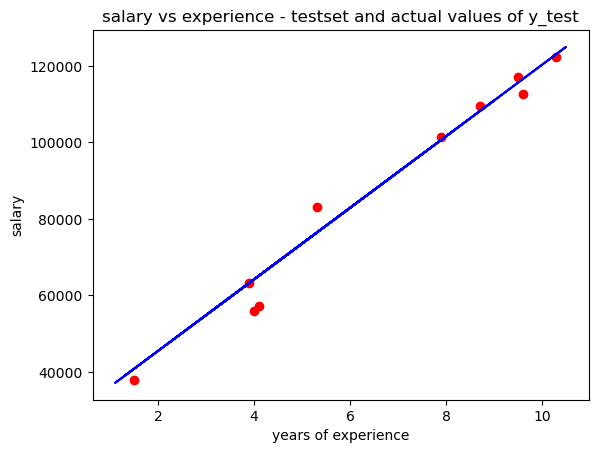

In [55]:
#visualization
plt.scatter(x_test,y_test,color="red")
plt.plot(x_train,reg.predict(x_train),color="blue")
plt.title("salary vs experience - testset and actual values of y_test")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()